In [23]:
5

5

In [25]:
import pandas as pd
import random
import numpy as np

In [16]:
sample_space = list()
for i in range(10000):
    dice_1 = random.randint(1,6)
    dice_2 = random.randint(1,6)
    sample_space.append( (dice_1 + dice_2) )

times_ = pd.Series(sample_space).value_counts()
print(times_)

7     1677
6     1421
8     1390
5     1105
9     1090
4      835
10     806
3      569
11     549
2      303
12     255
Name: count, dtype: int64


In [20]:
probablity = (times_/10000).sort_index()
probablity

2     0.0303
3     0.0569
4     0.0835
5     0.1105
6     0.1421
7     0.1677
8     0.1390
9     0.1090
10    0.0806
11    0.0549
12    0.0255
Name: count, dtype: float64

<Axes: >

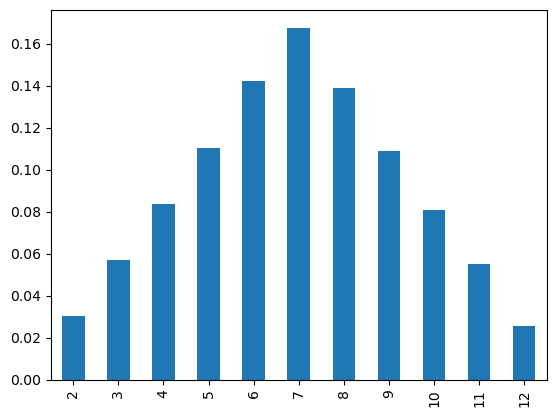

In [21]:
probablity.plot(kind='bar')

In [22]:
probablity

5

In [24]:
probablity

2     0.0303
3     0.0569
4     0.0835
5     0.1105
6     0.1421
7     0.1677
8     0.1390
9     0.1090
10    0.0806
11    0.0549
12    0.0255
Name: count, dtype: float64

<Axes: >

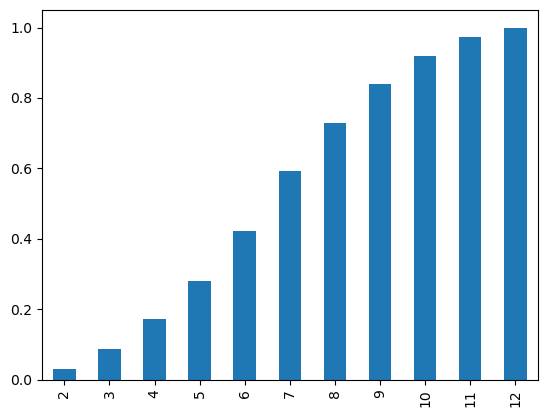

In [26]:
np.cumsum(probablity).plot(kind='bar')

In [27]:
5

5

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import normal

# here we create a 1000 points sample from normal distribution
sample = normal(loc=50, scale=5, size=1000)

(array([  1.,  10.,  51., 168., 254., 278., 148.,  75.,  11.,   4.]),
 array([31.8251617 , 35.41750868, 39.00985565, 42.60220262, 46.19454959,
        49.78689656, 53.37924353, 56.9715905 , 60.56393747, 64.15628444,
        67.74863141]),
 <BarContainer object of 10 artists>)

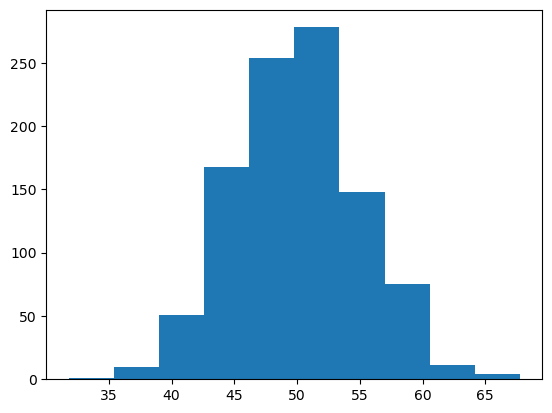

In [33]:
plt.hist(sample, bins=10)

In [34]:
# now we calculate sample mean and sample standerd deviation
# here sample mean and stander deviation are not exactily 50 and 5 because the data is sample from normal distribution
sample_mean = sample.mean()
sample_std = sample.std()
print(sample_mean, sample_std)

49.992541824508024 4.959012725657568


In [36]:
# fit the mean and std in the normal distribution equation
from scipy.stats import norm
dist = norm(sample_mean, sample_std)

In [37]:
# now we are generating points between min and max of sample distribution (or say Range)
values = np.linspace(sample.min(), sample.max(), 100)

In [39]:
# now we are generating the probablity density for the 100 values
probability_density = [dist.pdf(x) for x in values]

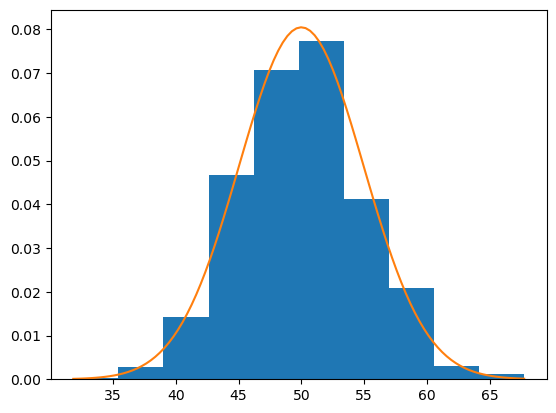

In [42]:
# generating the plot
plt.hist(sample, bins = 10, density=True)
plt.plot(values, probability_density)

In [43]:
5

5

<Axes: ylabel='Count'>

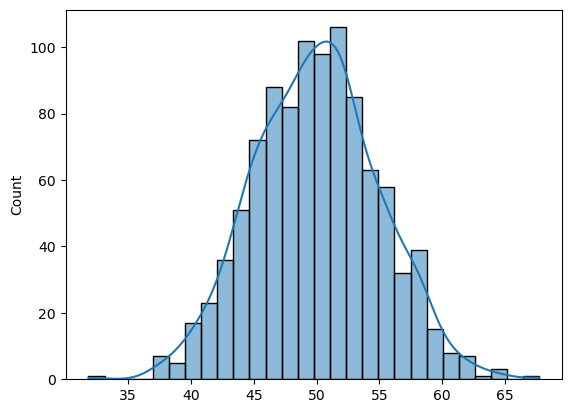

In [48]:
# This shows the bars and the estimated PDF line together
sns.histplot(sample, kde=True)

In [49]:
5

5

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import normal

# here we creating 1000 datapoints by merging two differet datasets
# we are doing so we can sumulate the distribution to did't match to any know distribution
sample_1 = normal(loc=20, scale=5, size=300)
sample_2 = normal(loc=40, scale=5, size=700)

# combining both columnwise
sample = np.hstack((sample_1, sample_2))
print(sample[:5])

[18.62000796 12.74621538 22.0385781  26.02933823 20.74549275]


(array([ 1.,  0.,  1.,  0.,  0.,  4.,  4.,  4., 13., 10.,  9.,  9., 21.,
        17., 26., 30., 19., 23., 23., 27., 14., 16., 12., 14., 12.,  5.,
         9., 17., 22., 27., 41., 41., 39., 56., 62., 61., 52., 64., 36.,
        41., 31., 18., 28., 13., 10.,  7.,  4.,  4.,  2.,  1.]),
 array([ 4.00390713,  5.02653233,  6.04915752,  7.07178272,  8.09440792,
         9.11703312, 10.13965832, 11.16228352, 12.18490872, 13.20753392,
        14.23015912, 15.25278432, 16.27540952, 17.29803472, 18.32065992,
        19.34328512, 20.36591032, 21.38853552, 22.41116072, 23.43378592,
        24.45641112, 25.47903632, 26.50166152, 27.52428672, 28.54691192,
        29.56953711, 30.59216231, 31.61478751, 32.63741271, 33.66003791,
        34.68266311, 35.70528831, 36.72791351, 37.75053871, 38.77316391,
        39.79578911, 40.81841431, 41.84103951, 42.86366471, 43.88628991,
        44.90891511, 45.93154031, 46.95416551, 47.97679071, 48.99941591,
        50.02204111, 51.04466631, 52.06729151, 53.0899167 ,

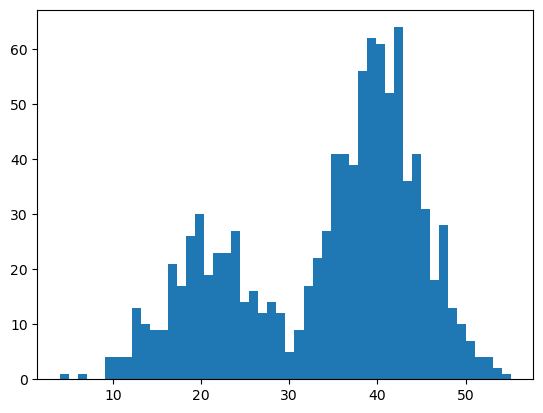

In [51]:
plt.hist(sample, bins=50)

In [63]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=0.5, kernel='gaussian')
# convert the data in 2d because machine leraing algorithm works in 2d
sample = sample.reshape(len(sample), 1)
model.fit(sample)

KernelDensity(bandwidth=0.5)

In [64]:
values = np.linspace(sample.min(), sample.max(), 100)
values = values.reshape((len(values), 1))

In [65]:
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)

In [66]:
5555

5555

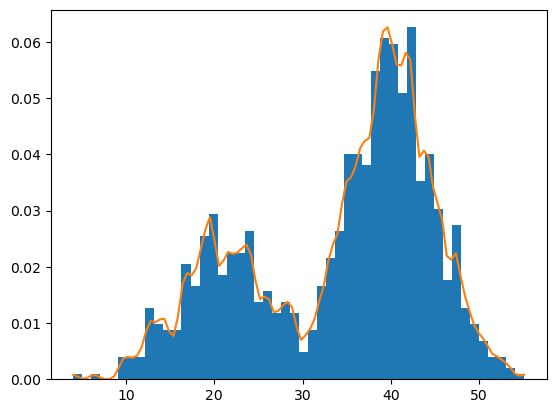

In [67]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()

In [61]:
5sdd

SyntaxError: invalid decimal literal (71982467.py, line 1)

<Axes: ylabel='Density'>

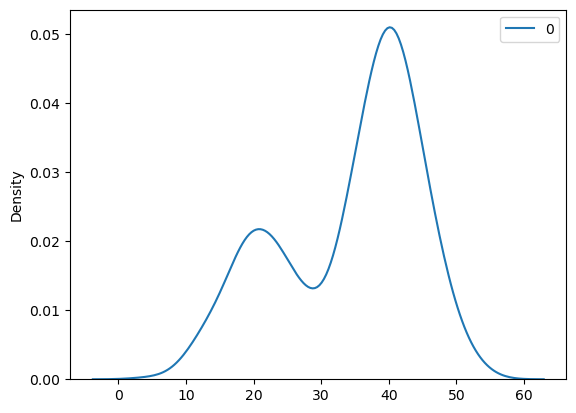

In [68]:
sns.kdeplot(sample)